# 📊 FASE 2: EDA (Exploratory Data Analysis)

__Objetivo__: Entender profundamente el dataset, identificar patrones, detectar problemas de calidad y sentar las bases para el feature engineering.

---

### Imports y Configuración

In [1]:
# Imports básicos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

%matplotlib inline

print("✅ Librerías importadas correctamente")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Librerías importadas correctamente
Pandas version: 2.3.3
NumPy version: 2.3.5


### Carga de Datos

In [4]:
# Cargar dataset principal
df = pd.read_csv('../data/raw/application_train.csv')

print("=" * 80)
print("📊 DATASET CARGADO EXITOSAMENTE")
print("=" * 80)
print(f"\n🔢 Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"💾 Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n📋 Primeras 3 filas:")
display(df.head(3))

📊 DATASET CARGADO EXITOSAMENTE

🔢 Dimensiones: 307,511 filas x 122 columnas
💾 Tamaño en memoria: 536.69 MB

📋 Primeras 3 filas:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

### Inspección General

In [5]:
# Información general del dataset
print("=" * 80)
print("🔍 INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)

print("\n📊 Tipos de datos:")
print(df.dtypes.value_counts())

print("\n🎯 Variable Target (TARGET):")
print(df['TARGET'].value_counts())
print(f"\nDistribución:")
print(df['TARGET'].value_counts(normalize=True).mul(100).round(2))

# Identificar tipos de columnas
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n📈 Variables numéricas: {len(numerical_cols)}")
print(f"📊 Variables categóricas: {len(categorical_cols)}")

# Guardar en variable para uso posterior
print(f"\n✅ Columnas identificadas y guardadas")

🔍 INFORMACIÓN GENERAL DEL DATASET

📊 Tipos de datos:
float64    65
int64      41
object     16
Name: count, dtype: int64

🎯 Variable Target (TARGET):
TARGET
0    282686
1     24825
Name: count, dtype: int64

Distribución:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

📈 Variables numéricas: 106
📊 Variables categóricas: 16

✅ Columnas identificadas y guardadas


### Análisis de Missing Values

❌ ANÁLISIS DE MISSING VALUES

📊 Columnas con missing values: 67/122

🔝 Top 15 columnas con más missing:
                 columna  missing_count  missing_pct_%
         COMMONAREA_MEDI         214865          69.87
          COMMONAREA_AVG         214865          69.87
         COMMONAREA_MODE         214865          69.87
NONLIVINGAPARTMENTS_MEDI         213514          69.43
NONLIVINGAPARTMENTS_MODE         213514          69.43
 NONLIVINGAPARTMENTS_AVG         213514          69.43
      FONDKAPREMONT_MODE         210295          68.39
   LIVINGAPARTMENTS_MODE         210199          68.35
   LIVINGAPARTMENTS_MEDI         210199          68.35
    LIVINGAPARTMENTS_AVG         210199          68.35
          FLOORSMIN_MODE         208642          67.85
          FLOORSMIN_MEDI         208642          67.85
           FLOORSMIN_AVG         208642          67.85
        YEARS_BUILD_MODE         204488          66.50
        YEARS_BUILD_MEDI         204488          66.50


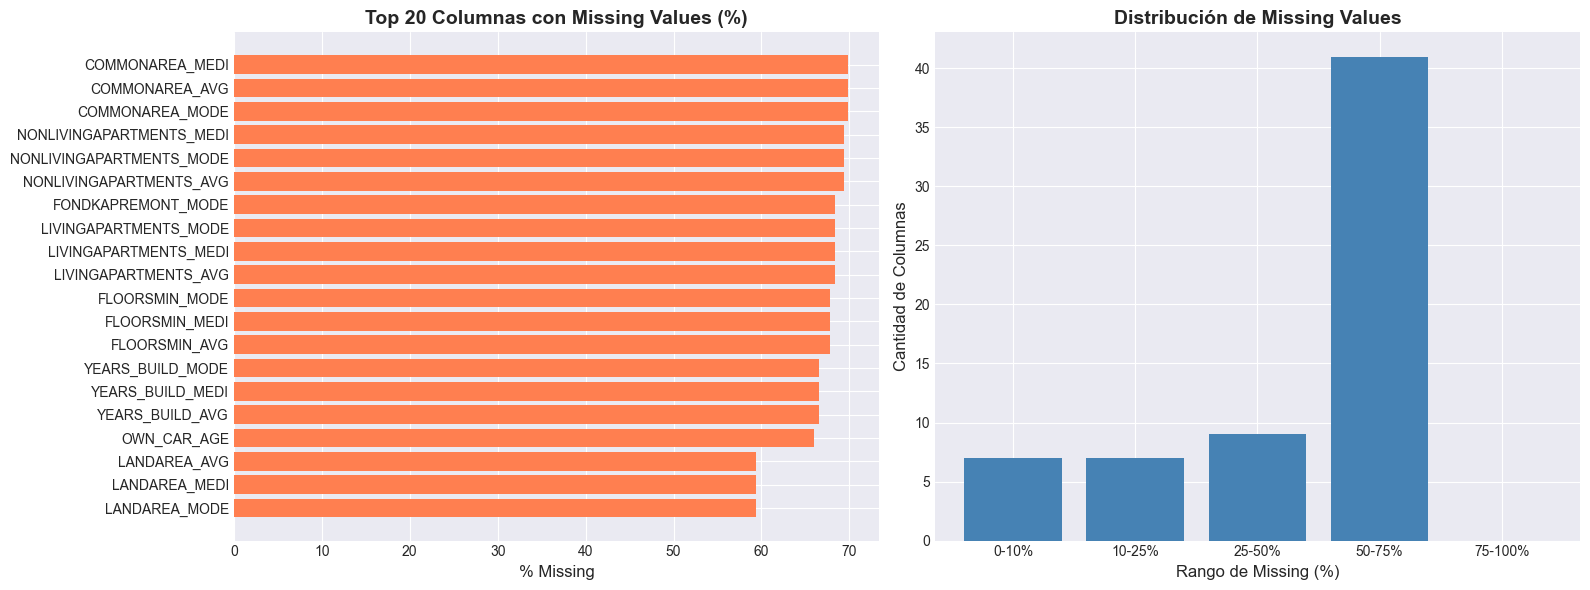


💡 DECISIÓN ESTRATÉGICA:
   - Columnas con >70% missing: 0 → Candidatas a eliminar
   - Columnas con 20-70% missing: 50 → Imputación cuidadosa
   - Columnas con <20% missing: 17 → Imputación estándar


In [6]:
# Calcular missing values
missing = pd.DataFrame({
    'columna': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_pct_%': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing['missing_count'] > 0].sort_values('missing_pct_%', ascending=False)

print("=" * 80)
print("❌ ANÁLISIS DE MISSING VALUES")
print("=" * 80)
print(f"\n📊 Columnas con missing values: {len(missing)}/{df.shape[1]}")
print(f"\n🔝 Top 15 columnas con más missing:")
print(missing.head(15).to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Cantidad de missing por columna
missing_top20 = missing.head(20)
axes[0].barh(missing_top20['columna'], missing_top20['missing_pct_%'], color='coral')
axes[0].set_xlabel('% Missing', fontsize=12)
axes[0].set_title('Top 20 Columnas con Missing Values (%)', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Gráfico 2: Distribución de missing
missing_distribution = pd.cut(missing['missing_pct_%'], 
                               bins=[0, 10, 25, 50, 75, 100],
                               labels=['0-10%', '10-25%', '25-50%', '50-75%', '75-100%'])
missing_dist_counts = missing_distribution.value_counts().sort_index()
axes[1].bar(missing_dist_counts.index, missing_dist_counts.values, color='steelblue')
axes[1].set_xlabel('Rango de Missing (%)', fontsize=12)
axes[1].set_ylabel('Cantidad de Columnas', fontsize=12)
axes[1].set_title('Distribución de Missing Values', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Decisión estratégica
print("\n💡 DECISIÓN ESTRATÉGICA:")
print(f"   - Columnas con >70% missing: {len(missing[missing['missing_pct_%'] > 70])} → Candidatas a eliminar")
print(f"   - Columnas con 20-70% missing: {len(missing[(missing['missing_pct_%'] >= 20) & (missing['missing_pct_%'] <= 70)])} → Imputación cuidadosa")
print(f"   - Columnas con <20% missing: {len(missing[missing['missing_pct_%'] < 20])} → Imputación estándar")

__Del gráfico anterior podemos concluir lo siguiente: La distribución del porcentaje de valores faltantes presenta una fuerte asimetría positiva, con concentración extrema en rangos superiores al 50%, lo que sugiere un patrón de missing no aleatorio (MNAR) y una estructura de datos fragmentada. Esto invalida, en este grupo de columnas con rangos del 50-75%, el uso de estrategias globales de imputación  y sugiere la necesidad de enfoques segmentados o reducción dimensional.__

### Análisis del Target (Variable Objetivo)

🎯 ANÁLISIS PROFUNDO DE LA VARIABLE TARGET

📊 Distribución:
   - No Default (0): 282,686 (91.93%)
   - Default (1):    24,825 (8.07%)

⚠️  Desbalance de clases: 11.4:1


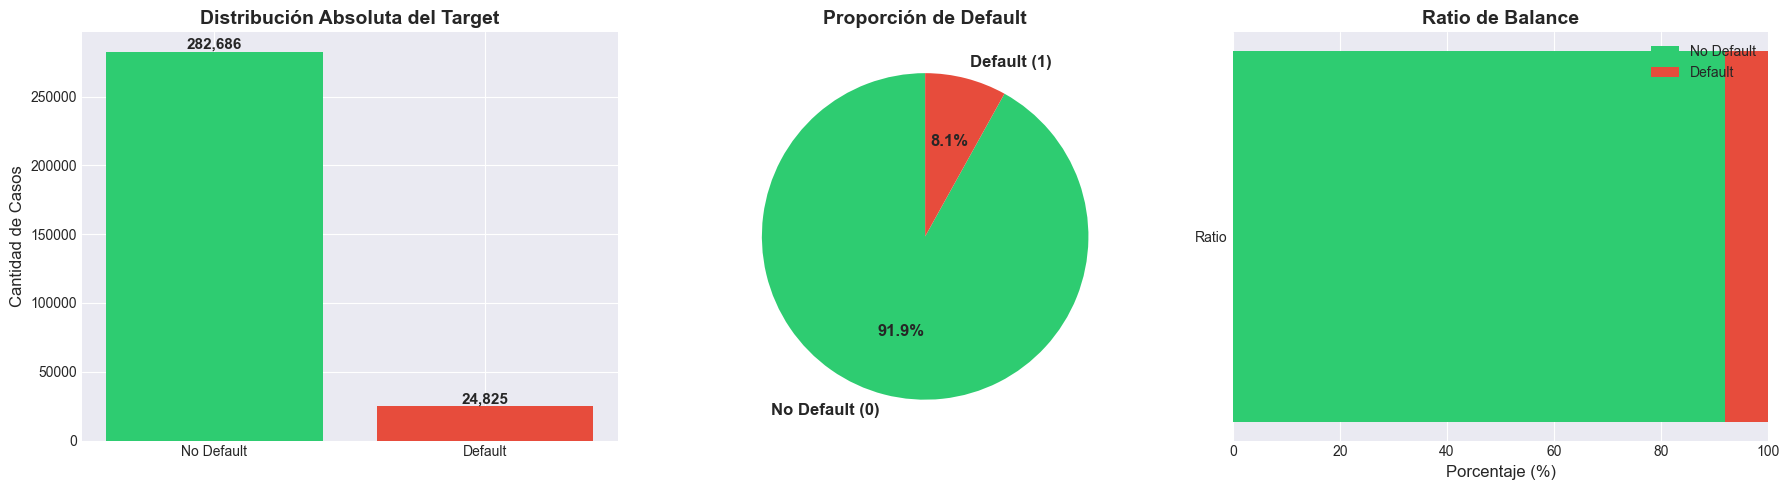


💡 DEDUCCIÓN:

Aunque el gráfico es discreto, podemos decir que responde a:
 Una Distibución Bernoulli desbalanceada.

💡 IMPLICACIONES:
   ✓ Usaremos SMOTE para balancear clases en el modelado
   ✓ Métricas clave: ROC-AUC, Precision, Recall (no solo Accuracy)
   ✓ Validación estratificada obligatoria


In [10]:
print("=" * 80)
print("🎯 ANÁLISIS PROFUNDO DE LA VARIABLE TARGET")
print("=" * 80)

# Calcular estadísticas
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True).mul(100)

print(f"\n📊 Distribución:")
print(f"   - No Default (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"   - Default (1):    {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"\n⚠️  Desbalance de clases: {target_pct[0]/target_pct[1]:.1f}:1")

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Conteo absoluto
axes[0].bar(['No Default', 'Default'], target_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Cantidad de Casos', fontsize=12)
axes[0].set_title('Distribución Absoluta del Target', fontsize=14, fontweight='bold')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Gráfico 2: Porcentajes
colors_pie = ['#2ecc71', '#e74c3c']
axes[1].pie(target_counts.values, labels=['No Default (0)', 'Default (1)'], 
            autopct='%1.1f%%', colors=colors_pie, startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporción de Default', fontsize=14, fontweight='bold')

# Gráfico 3: Ratio visual
axes[2].barh(['Ratio'], [target_pct[0]], color='#2ecc71', label='No Default')
axes[2].barh(['Ratio'], [target_pct[1]], left=[target_pct[0]], color='#e74c3c', label='Default')
axes[2].set_xlabel('Porcentaje (%)', fontsize=12)
axes[2].set_title('Ratio de Balance', fontsize=14, fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].set_xlim(0, 100)

plt.tight_layout()
plt.show()

print("\n💡 DEDUCCIÓN:")
print("\nAunque el gráfico es discreto, podemos decir que responde a:\n Una Distibución Bernoulli desbalanceada.")
print("\n💡 IMPLICACIONES:")
print("   ✓ Usaremos SMOTE para balancear clases en el modelado")
print("   ✓ Métricas clave: ROC-AUC, Precision, Recall (no solo Accuracy)")
print("   ✓ Validación estratificada obligatoria")



__Ahora como deducción luego de ver y entender este gráfico puedo inferir que la variable objetivo presenta un fuerte desvalance de clases, con una proporción aproximada de 92% de no-default y 8% de default, lo que induce una baja entropía y hace que métricas globales como accuracy resulten engañosas. El problema debe ser abordado como una tarea de clasificación asimétrica, priorizando métricas sensibles a la clase minoritaria y estrategias de aprendizaje con ponderación de clases o remuestreo.__

### Análisis de Variables Numéricas Clave

📈 ANÁLISIS DE VARIABLES NUMÉRICAS CLAVE

📊 Estadísticas Descriptivas:
                     count       mean        std      min       25%       50%  \
AMT_INCOME_TOTAL  307511.0  168797.92  237123.15  25650.0  112500.0  147150.0   
AMT_CREDIT        307511.0  599026.00  402490.78  45000.0  270000.0  513531.0   
AMT_ANNUITY       307499.0   27108.57   14493.74   1615.5   16524.0   24903.0   
AMT_GOODS_PRICE   307233.0  538396.21  369446.46  40500.0  238500.0  450000.0   
DAYS_BIRTH        307511.0  -16037.00    4363.99 -25229.0  -19682.0  -15750.0   
DAYS_EMPLOYED     307511.0   63815.05  141275.77 -17912.0   -2760.0   -1213.0   
CNT_CHILDREN      307511.0       0.42       0.72      0.0       0.0       0.0   
CNT_FAM_MEMBERS   307509.0       2.15       0.91      1.0       2.0       2.0   

                       75%          max  missing_pct_%  
AMT_INCOME_TOTAL  202500.0  117000000.0           0.00  
AMT_CREDIT        808650.0    4050000.0           0.00  
AMT_ANNUITY        34596.0   

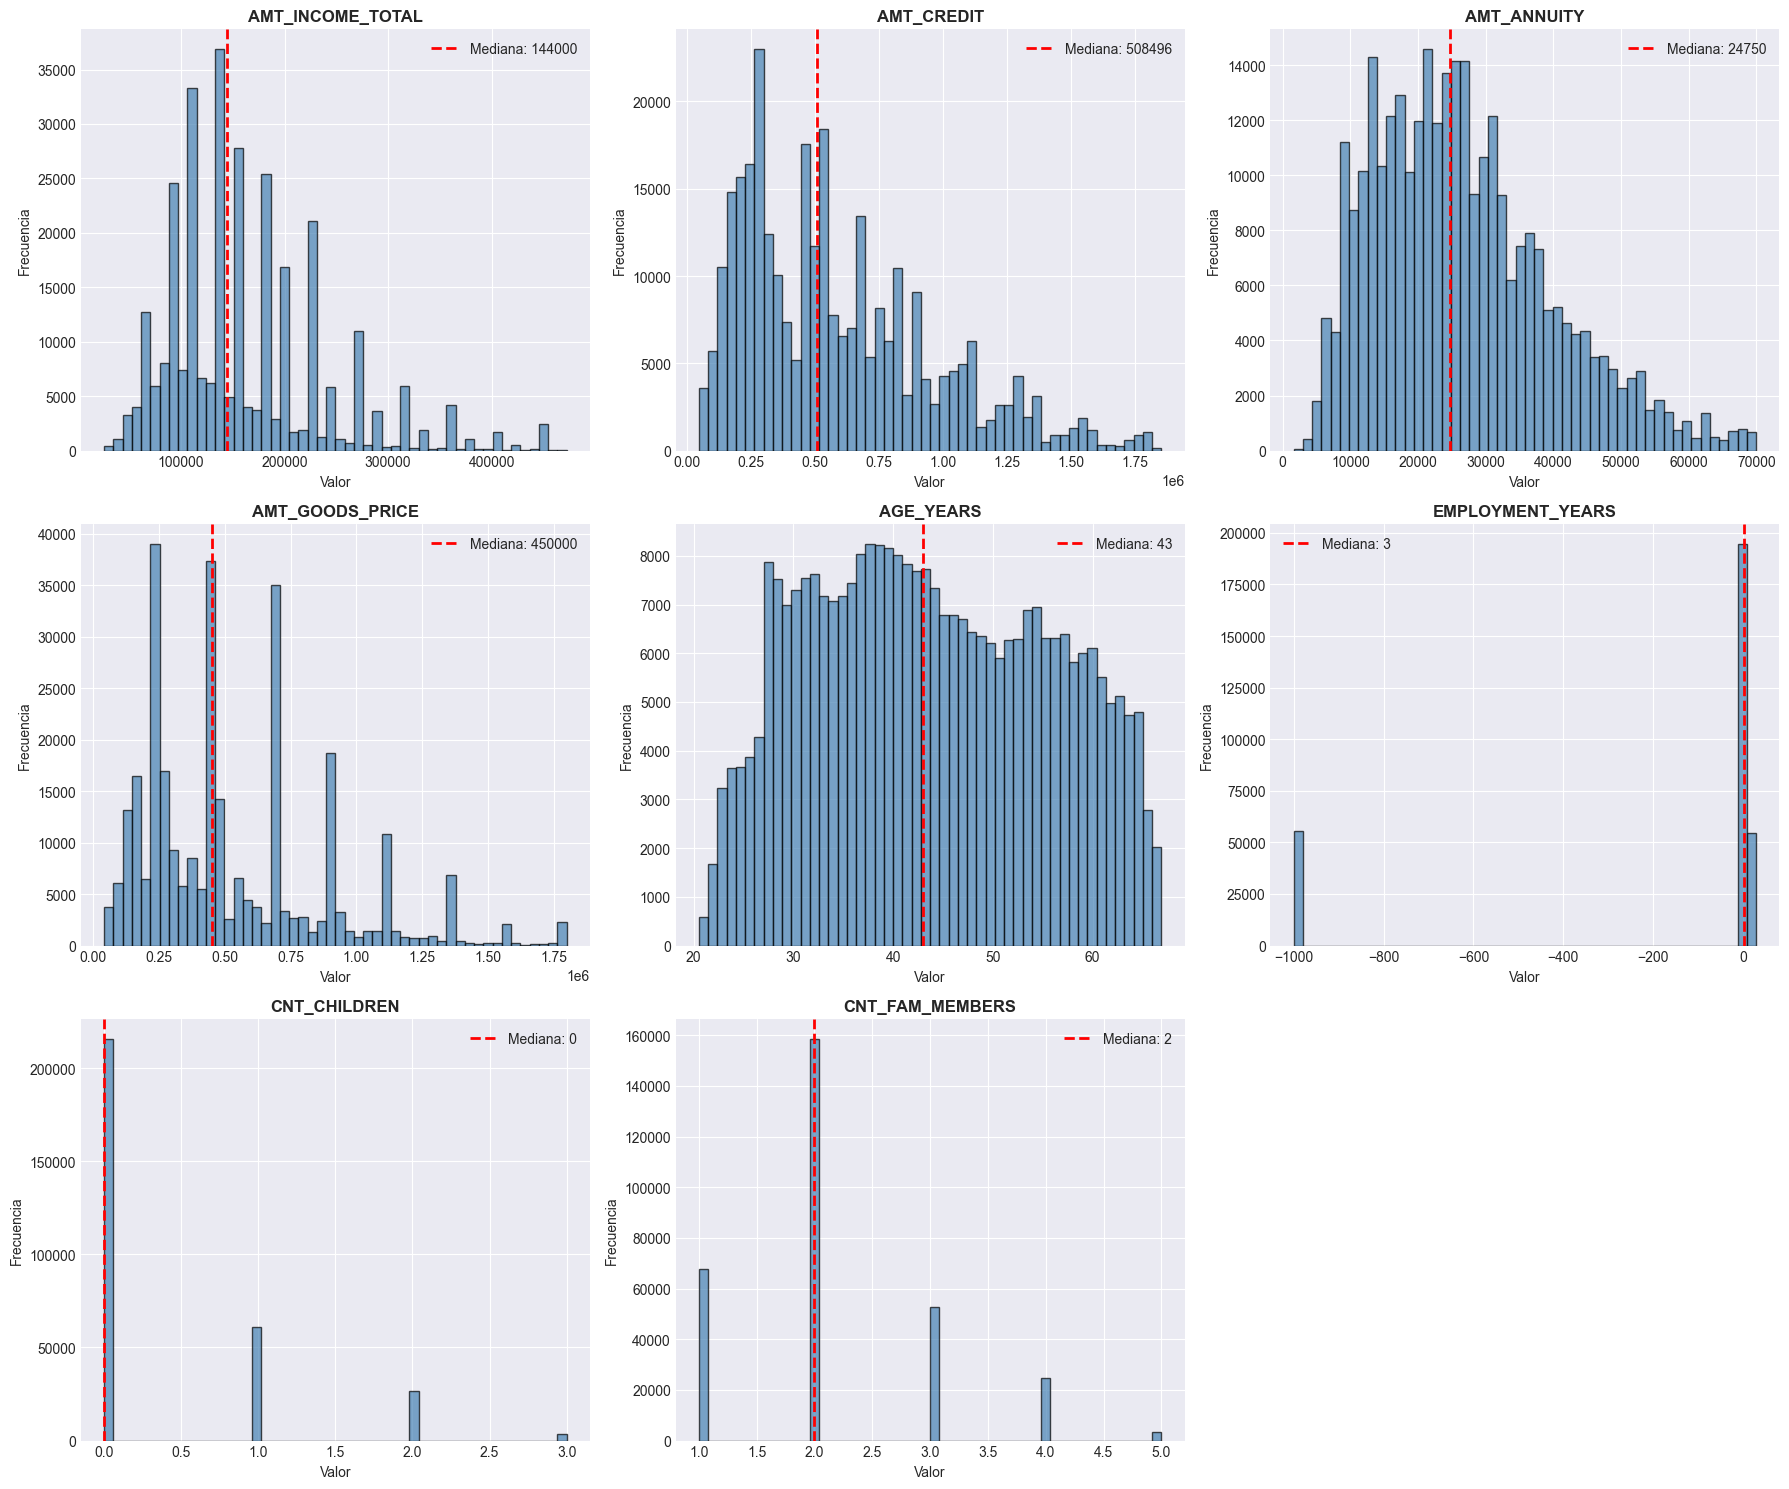


💡 INSIGHTS INICIALES:
   - Edad promedio: 44 años
   - Ingreso mediano: $147,150
   - Crédito mediano: $513,531
   - Años de empleo mediano: 3.3 años


In [20]:
print("=" * 80)
print("📈 ANÁLISIS DE VARIABLES NUMÉRICAS CLAVE")
print("=" * 80)

# Variables de interés para micro-préstamos
key_vars = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 
            'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']

# Verificar que existen
key_vars = [v for v in key_vars if v in df.columns]

# Estadísticas descriptivas
print("\n📊 Estadísticas Descriptivas:")
stats = df[key_vars].describe().T
stats['missing_pct_%'] = df[key_vars].isnull().sum() / len(df) * 100
print(stats.round(2))

# Transformar variables de días a formato legible
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365
df['EMPLOYMENT_YEARS'] = -df['DAYS_EMPLOYED'] / 365

# Limpiar valores anómalos en EMPLOYMENT_YEARS (365243 días = valor nulo codificado)
df['EMPLOYMENT_YEARS'] = df['EMPLOYMENT_YEARS'].replace(1000.665, np.nan)

# Visualización
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Variables a visualizar
viz_vars = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 
            'AMT_GOODS_PRICE', 'AGE_YEARS', 'EMPLOYMENT_YEARS', 
            'CNT_CHILDREN', 'CNT_FAM_MEMBERS']

for i, var in enumerate(viz_vars):
    if var in df.columns:
        # Limpiar outliers extremos para visualización
        q99 = df[var].quantile(0.99)
        data_viz = df[df[var] <= q99][var].dropna()
        
        axes[i].hist(data_viz, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{var}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Valor', fontsize=10)
        axes[i].set_ylabel('Frecuencia', fontsize=10)
        axes[i].axvline(data_viz.median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: {data_viz.median():.0f}')
        axes[i].legend()

# Ocultar último subplot si sobra
if len(viz_vars) < 9:
    axes[8].axis('off')

plt.tight_layout()
plt.show()

print("\n💡 INSIGHTS INICIALES:")
print(f"   - Edad promedio: {df['AGE_YEARS'].mean():.0f} años")
print(f"   - Ingreso mediano: ${df['AMT_INCOME_TOTAL'].median():,.0f}")
print(f"   - Crédito mediano: ${df['AMT_CREDIT'].median():,.0f}")
print(f"   - Años de empleo mediano: {df['EMPLOYMENT_YEARS'].median():.1f} años")




### Análisis de Variables Categóricas Clave

📊 ANÁLISIS DE VARIABLES CATEGÓRICAS CLAVE

📌 CODE_GENDER:
Categoría  Cantidad  Porcentaje
        F    202448       65.83
        M    105059       34.16
      XNA         4        0.00

📌 NAME_INCOME_TYPE:
           Categoría  Cantidad  Porcentaje
             Working    158774       51.63
Commercial associate     71617       23.29
           Pensioner     55362       18.00
       State servant     21703        7.06
          Unemployed        22        0.01
             Student        18        0.01
         Businessman        10        0.00
     Maternity leave         5        0.00

📌 NAME_EDUCATION_TYPE:
                    Categoría  Cantidad  Porcentaje
Secondary / secondary special    218391       71.02
             Higher education     74863       24.34
            Incomplete higher     10277        3.34
              Lower secondary      3816        1.24
              Academic degree       164        0.05

📌 NAME_FAMILY_STATUS:
           Categoría  Cantidad  Porcentaje
    

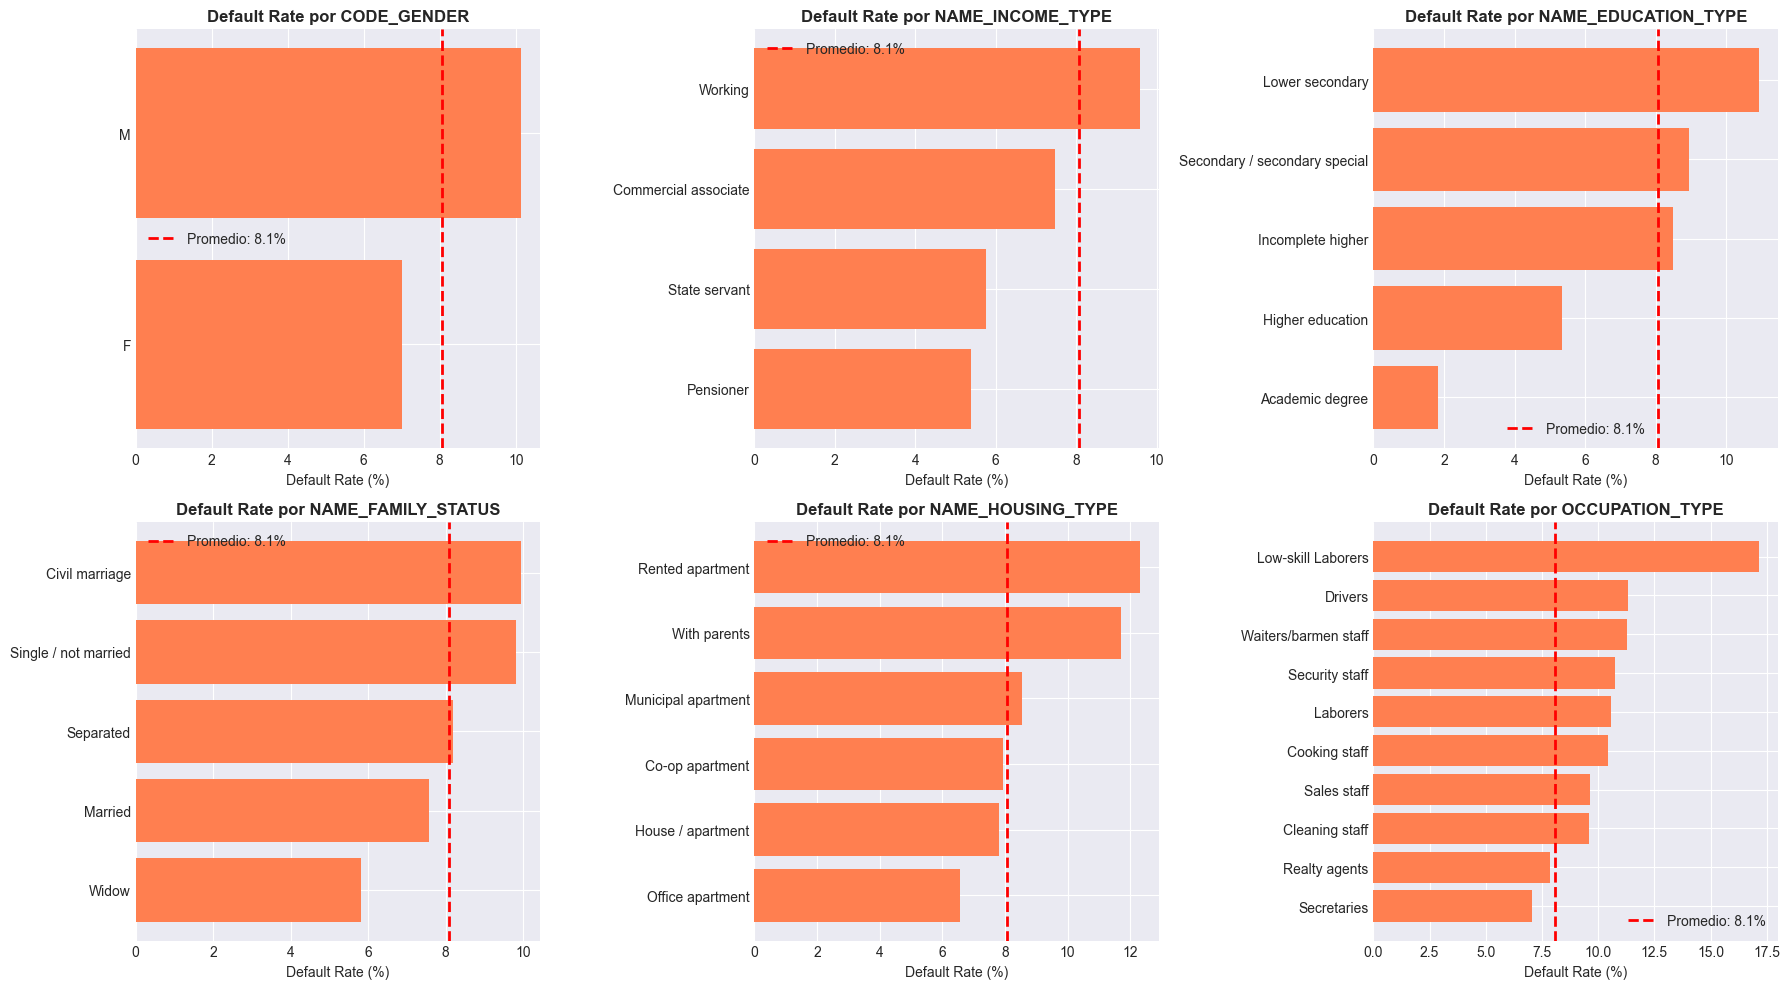


💡 VARIABLES CON POTENCIAL PREDICTIVO:
   ✓ NAME_INCOME_TYPE: Diferentes tipos de ingreso tienen default rates distintos
   ✓ NAME_EDUCATION_TYPE: Educación correlaciona con solvencia
   ✓ OCCUPATION_TYPE: Ocupación puede indicar estabilidad


In [16]:
print("=" * 80)
print("📊 ANÁLISIS DE VARIABLES CATEGÓRICAS CLAVE")
print("=" * 80)

# Variables categóricas de interés
cat_vars = ['CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 
            'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

cat_vars = [v for v in cat_vars if v in df.columns]

# Análisis de cada variable
for var in cat_vars:
    print(f"\n📌 {var}:")
    value_counts = df[var].value_counts()
    value_pcts = df[var].value_counts(normalize=True).mul(100).round(2)
    
    print(pd.DataFrame({
        'Categoría': value_counts.index,
        'Cantidad': value_counts.values,
        'Porcentaje': value_pcts.values
    }).head(10).to_string(index=False))

# Visualización: Default rate por categoría
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    if var in df.columns:
        # Calcular default rate por categoría
        default_by_cat = df.groupby(var)['TARGET'].agg(['mean', 'count']).reset_index()
        default_by_cat = default_by_cat[default_by_cat['count'] > 100]  # Filtrar categorías pequeñas
        default_by_cat = default_by_cat.sort_values('mean', ascending=False).head(10)
        
        axes[i].barh(default_by_cat[var], default_by_cat['mean'] * 100, color='coral')
        axes[i].set_xlabel('Default Rate (%)', fontsize=10)
        axes[i].set_title(f'Default Rate por {var}', fontsize=12, fontweight='bold')
        axes[i].axvline(df['TARGET'].mean() * 100, color='red', linestyle='--', 
                        linewidth=2, label=f'Promedio: {df["TARGET"].mean()*100:.1f}%')
        axes[i].legend()
        axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n💡 VARIABLES CON POTENCIAL PREDICTIVO:")
print("   ✓ NAME_INCOME_TYPE: Diferentes tipos de ingreso tienen default rates distintos")
print("   ✓ NAME_EDUCATION_TYPE: Educación correlaciona con solvencia")
print("   ✓ OCCUPATION_TYPE: Ocupación puede indicar estabilidad")

### Identificación de Variables para Feature Engineering

In [17]:
print("=" * 80)
print("🔧 IDENTIFICACIÓN DE VARIABLES PARA FEATURE ENGINEERING")
print("=" * 80)

# Variables que nos permitirán crear features alternativos
print("\n✅ VARIABLES DISPONIBLES PARA SCORING ALTERNATIVO:")

# 1. Estabilidad de ingresos
print("\n1️⃣ ESTABILIDAD DE INGRESOS:")
income_vars = [col for col in df.columns if 'AMT_INCOME' in col or 'INCOME' in col]
print(f"   Variables: {income_vars}")

# 2. Historial de pagos (proxies)
print("\n2️⃣ HISTORIAL DE PAGOS:")
payment_vars = [col for col in df.columns if 'AMT_ANNUITY' in col or 'CREDIT' in col]
print(f"   Variables: {payment_vars}")

# 3. Arraigo (estabilidad residencial/laboral)
print("\n3️⃣ ARRAIGO:")
stability_vars = ['DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 
                  'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION']
stability_vars = [v for v in stability_vars if v in df.columns]
print(f"   Variables: {stability_vars}")

# 4. Inclusión financiera/digital
print("\n4️⃣ INCLUSIÓN FINANCIERA:")
inclusion_vars = [col for col in df.columns if 'FLAG' in col and 'PHONE' in col or 'DOCUMENT' in col]
print(f"   Variables disponibles: {len(inclusion_vars)}")
print(f"   Ejemplos: {inclusion_vars[:5]}")

# 5. Composición familiar (contexto social)
print("\n5️⃣ CONTEXTO SOCIAL:")
social_vars = ['CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_FAMILY_STATUS']
print(f"   Variables: {social_vars}")

print("\n" + "=" * 80)
print("🎯 FEATURES ALTERNATIVOS A CREAR EN PRÓXIMA FASE:")
print("=" * 80)
print("""
   ✓ income_stability_score: Basado en tipo de ingreso y empleo
   ✓ payment_capacity_ratio: AMT_CREDIT / AMT_INCOME_TOTAL
   ✓ employment_stability: Años de empleo normalizado
   ✓ address_tenure_score: DAYS_REGISTRATION / edad
   ✓ financial_inclusion_score: Suma de flags de documentos/teléfono
   ✓ family_dependency_ratio: CNT_CHILDREN / CNT_FAM_MEMBERS
   ✓ credit_utilization: AMT_CREDIT / AMT_GOODS_PRICE
   ✓ annuity_income_ratio: AMT_ANNUITY / AMT_INCOME_TOTAL
""")

🔧 IDENTIFICACIÓN DE VARIABLES PARA FEATURE ENGINEERING

✅ VARIABLES DISPONIBLES PARA SCORING ALTERNATIVO:

1️⃣ ESTABILIDAD DE INGRESOS:
   Variables: ['AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE']

2️⃣ HISTORIAL DE PAGOS:
   Variables: ['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']

3️⃣ ARRAIGO:
   Variables: ['DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION']

4️⃣ INCLUSIÓN FINANCIERA:
   Variables disponibles: 23
   Ejemplos: ['FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3']

5️⃣ CONTEXTO SOCIAL:
   Variables: ['CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_FAMILY_STATUS']

🎯 FEATURES ALTERNATIVOS A CREAR EN PRÓXIMA FASE:

   ✓ income_stability_score: Basado en tipo de ingreso y empleo
   ✓ payment_capacity_ratio: AMT_CREDIT / AMT_INC

### Correlaciones con Target

🔗 ANÁLISIS DE CORRELACIONES CON TARGET

📈 TOP 15 CORRELACIONES POSITIVAS (↑ riesgo de default):
LIVINGAREA_MEDI              -0.032739
LIVINGAREA_AVG               -0.032997
FLOORSMIN_MEDI               -0.033394
FLOORSMIN_AVG                -0.033614
ELEVATORS_MEDI               -0.033863
ELEVATORS_AVG                -0.034199
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
FLOORSMAX_MODE               -0.043226
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_AVG                -0.044003
DAYS_EMPLOYED                -0.044932
EXT_SOURCE_1                 -0.155317
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919

📉 TOP 15 CORRELACIONES NEGATIVAS (↓ riesgo de default):
TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY

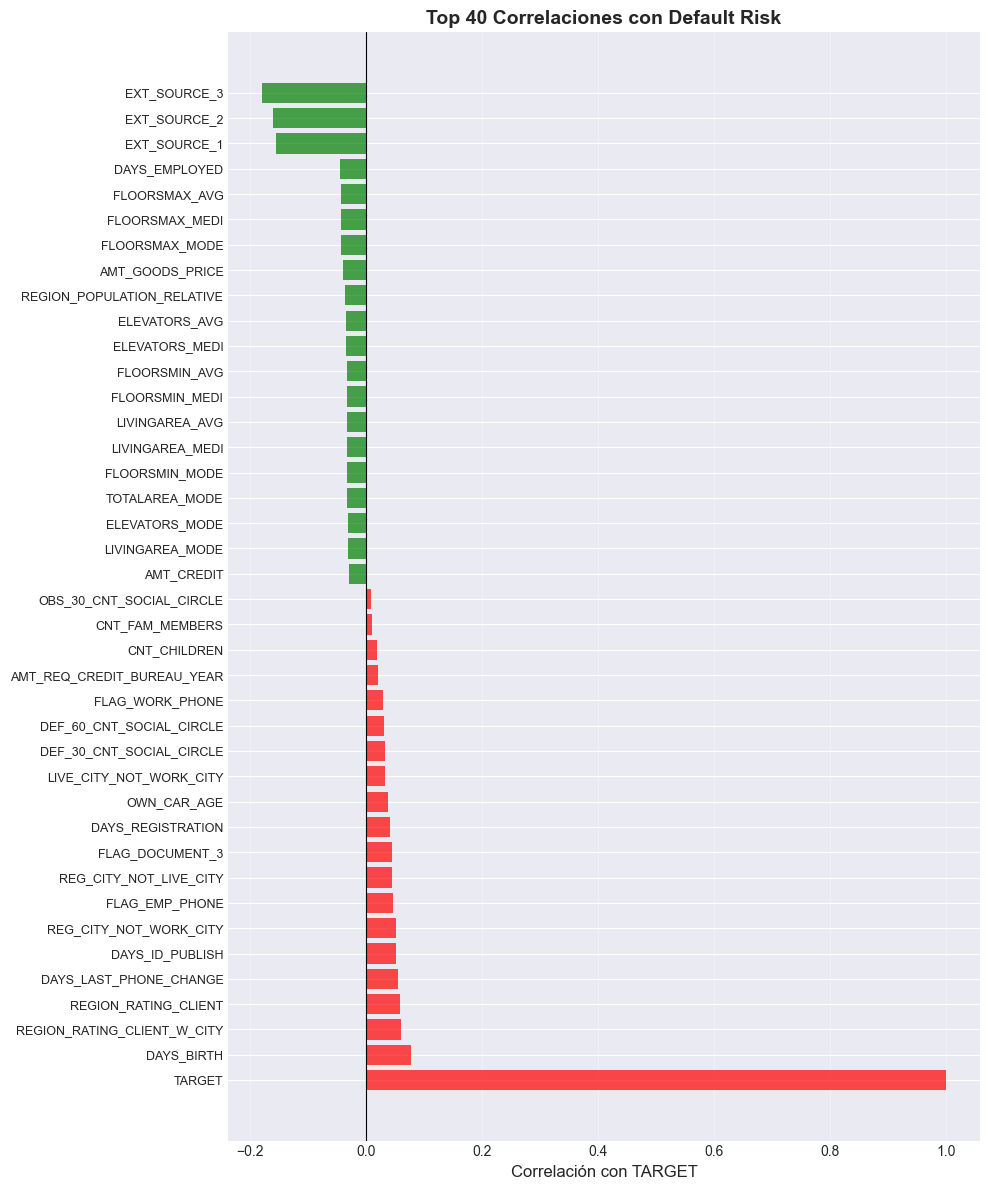


💡 INSIGHTS CLAVE:
   ✓ Variables EXT_SOURCE_X tienen correlación negativa fuerte → protectoras
   ✓ DAYS_BIRTH negativo → personas más jóvenes tienen mayor riesgo
   ✓ REGION_RATING tiene correlación → contexto geográfico importa


In [24]:
print("=" * 80)
print("🔗 ANÁLISIS DE CORRELACIONES CON TARGET")
print("=" * 80)

# Calcular correlaciones
numerical_for_corr = df[numerical_cols].select_dtypes(include=['int64', 'float64'])
correlations = numerical_for_corr.corrwith(df['TARGET']).sort_values(ascending=False)

# Top correlaciones positivas y negativas
print("\n📈 TOP 15 CORRELACIONES POSITIVAS (↑ riesgo de default):")
print(correlations.tail(15).to_string())

print("\n📉 TOP 15 CORRELACIONES NEGATIVAS (↓ riesgo de default):")
print(correlations.head(15).to_string())

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

top_corrs = pd.concat([correlations.head(20), correlations.tail(20)])
colors = ['green' if x < 0 else 'red' for x in top_corrs.values]

ax.barh(range(len(top_corrs)), top_corrs.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(top_corrs)))
ax.set_yticklabels(top_corrs.index, fontsize=9)
ax.set_xlabel('Correlación con TARGET', fontsize=12)
ax.set_title('Top 40 Correlaciones con Default Risk', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHTS CLAVE:")
print("   ✓ Variables EXT_SOURCE_X tienen correlación negativa fuerte → protectoras")
print("   ✓ DAYS_BIRTH negativo → personas más jóvenes tienen mayor riesgo")
print("   ✓ REGION_RATING tiene correlación → contexto geográfico importa")

### Resumen y Conclusiones

In [19]:
print("=" * 80)
print("📋 RESUMEN EJECUTIVO DEL EDA")
print("=" * 80)

print(f"""
📊 DATOS:
   - Total de registros: {df.shape[0]:,}
   - Total de variables: {df.shape[1]}
   - Variables numéricas: {len(numerical_cols)}
   - Variables categóricas: {len(categorical_cols)}
   - Target desbalanceado: {df['TARGET'].mean()*100:.2f}% defaults

❌ CALIDAD DE DATOS:
   - Columnas con missing: {len(missing)}/{df.shape[1]}
   - Columnas con >70% missing: {len(missing[missing['missing_pct_%'] > 70])}
   - Requiere limpieza e imputación

🎯 VARIABLES CLAVE IDENTIFICADAS:
   ✓ AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY
   ✓ DAYS_BIRTH (edad), DAYS_EMPLOYED (experiencia)
   ✓ EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 (scores externos)
   ✓ NAME_INCOME_TYPE, NAME_EDUCATION_TYPE, OCCUPATION_TYPE

🔧 PRÓXIMOS PASOS (Feature Engineering):
   1. Crear features de estabilidad de ingresos
   2. Crear ratios financieros (deuda/ingreso, crédito/bien)
   3. Transformar variables temporales (días → años)
   4. Crear score de inclusión financiera
   5. Crear score de arraigo
   6. Imputar missing values
   7. Codificar variables categóricas
   8. Normalizar/escalar variables numéricas

💾 SIGUIENTE ACCIÓN:
   → Guardar variables clave para referencia
   → Crear notebook 02_Feature_Engineering.ipynb
""")

# Guardar lista de variables clave
key_variables = {
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'income_vars': income_vars,
    'payment_vars': payment_vars,
    'stability_vars': stability_vars,
    'target': 'TARGET'
}

# Guardar como referencia
import json
with open('../data/processed/key_variables.json', 'w') as f:
    json.dump(key_variables, f, indent=4)

print("\n✅ Variables clave guardadas en: data/processed/key_variables.json")

📋 RESUMEN EJECUTIVO DEL EDA

📊 DATOS:
   - Total de registros: 307,511
   - Total de variables: 124
   - Variables numéricas: 106
   - Variables categóricas: 16
   - Target desbalanceado: 8.07% defaults

❌ CALIDAD DE DATOS:
   - Columnas con missing: 67/124
   - Columnas con >70% missing: 0
   - Requiere limpieza e imputación

🎯 VARIABLES CLAVE IDENTIFICADAS:
   ✓ AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY
   ✓ DAYS_BIRTH (edad), DAYS_EMPLOYED (experiencia)
   ✓ EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 (scores externos)
   ✓ NAME_INCOME_TYPE, NAME_EDUCATION_TYPE, OCCUPATION_TYPE

🔧 PRÓXIMOS PASOS (Feature Engineering):
   1. Crear features de estabilidad de ingresos
   2. Crear ratios financieros (deuda/ingreso, crédito/bien)
   3. Transformar variables temporales (días → años)
   4. Crear score de inclusión financiera
   5. Crear score de arraigo
   6. Imputar missing values
   7. Codificar variables categóricas
   8. Normalizar/escalar variables numéricas

💾 SIGUIENTE ACCIÓN:
   → Gua

---

__Abraham Tartalos | Data Scientist__